In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import os
import json
from typing import List, Dict,TypedDict,Literal
# LangGraph imports
from langchain_core.tools import tool  # decorator to mark functions as tools
from langchain_aws import ChatBedrockConverse, BedrockEmbeddings
from langgraph.graph import StateGraph, END,START, MessagesState
from langgraph.prebuilt import create_react_agent, ToolNode
from IPython.display import Image, display
from langchain_core.messages import HumanMessage, AIMessage,SystemMessage, ToolMessage
from langchain_core.prompts import PromptTemplate,ChatPromptTemplate, MessagesPlaceholder
from langchain_core.runnables import RunnableLambda, RunnableConfig


/home/labuser/.local/lib/python3.10/site-packages/langgraph/cache/base/__init__.py:8: LangChainPendingDeprecationWarning: The default value of `allowed_objects` will change in a future version. Pass an explicit value (e.g., allowed_objects='messages' or allowed_objects='core') to suppress this warning.
  from langgraph.checkpoint.serde.jsonplus import JsonPlusSerializer


In [3]:

# ---------------------------
# AWS Bedrock LLM Setup
# ---------------------------
#llm = ChatBedrockConverse(model_id="amazon.nova-lite-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=50)
llm = ChatBedrockConverse(model_id="cohere.command-r-plus-v1:0", region_name="us-east-1", temperature=0.5, max_tokens=200)


In [4]:
@tool
def get_weather(city: str) -> str:
    """Return a one-line weather summary for 'city'."""
    # Replace this with real API call in production
    fake = {
        "Mysore": "23°C, partly cloudy",
        "New Delhi": "32°C, hot and humid",
        "Bangalore": "25°C, foggy"
    }
    return f"Weather in {city}: {fake.get(city, '20°C, clear skies')}"
@tool
def find_attractions(city: str) -> str:
    """Return a short list of top attractions for the city in JSON string form."""
    # Real implementation should call a places API and return structured data.
    attractions = {
        "Mysore": [
            {"name": "Mysore Palace", "type": "Hostorical", "visit_time_mins": 90},
            {"name": "Mysore Zoo", "type": "Zooloy", "visit_time_mins": 120},
            {"name": "Sand Meuseum", "type": "museum", "visit_time_mins": 60},
        ],
        "Bangalore": [
            {"name": "LalBagh", "type": "entertainment", "visit_time_mins": 60},
            {"name": "Planitorium", "type": "Education", "visit_time_mins": 90},
        ]
    }
    res = attractions.get(city, [])
    return json.dumps(res)
@tool
def get_directions(origin: str, destination: str) -> str:
    """Return a short route summary."""
    # Replace with call to directions API for real routing information.
    return f"Route from {origin} to {destination}: Drive ~30 mins (20 km) via Main St."
tools = [get_weather, find_attractions, get_directions]


In [5]:
tools_by_name = {tool.name: tool for tool in tools}
model_with_tools = llm.bind_tools(tools)


In [6]:
def call_llm(state: MessagesState):
    messages = [SystemMessage(content="You are a helpful assistant to suggest weather and attraction of the given Place."),] + state["messages"]
    return {"messages": [model_with_tools.invoke(messages)]}
def call_tool(state: MessagesState):
    result = []
    for tool_call in state["messages"][-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        observation = tool.invoke(tool_call["args"])
        result.append(ToolMessage(content=observation, tool_call_id=tool_call["id"]))
    return {"messages": result}
def should_continue(state: MessagesState) -> Literal["environment", END]:
    messages = state["messages"]
    last_message = messages[-1]
    if last_message.tool_calls:
        return "Action"
    return END


In [7]:
graph = StateGraph(MessagesState)
graph.add_node("llm", call_llm)
graph.add_node("environment", call_tool)
graph.add_edge(START, "llm")
graph.add_conditional_edges("llm",  should_continue, { "Action": "environment", END: END,},)
graph.add_edge("environment", "llm")
agent = graph.compile()


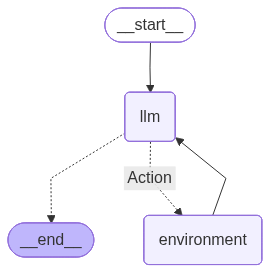

In [8]:
display(Image(agent.get_graph(xray=True).draw_mermaid_png()))


In [9]:
messages = [
    SystemMessage(content="You are a helpful  assistant to suggest weather and attractions"),
    HumanMessage(content="I want to plan a travel to Mysore"),
]
messages = agent.invoke({"messages": messages})
for m in messages["messages"]:
    m.pretty_print()


================================ System Message ================================

You are a helpful  assistant to suggest weather and attractions
================================ Human Message =================================

I want to plan a travel to Mysore
================================== Ai Message ==================================

[{'type': 'text', 'text': 'I will find the weather and attractions in Mysore and then write an answer.'}, {'type': 'tool_use', 'name': 'get_weather', 'input': {'city': 'Mysore'}, 'id': 'tooluse_ApgKmX0P9gxvDIVQyixwIY'}, {'type': 'tool_use', 'name': 'find_attractions', 'input': {'city': 'Mysore'}, 'id': 'tooluse_yeQYTl8PNqLD3PgfMqd7UO'}]
Tool Calls:
  get_weather (tooluse_ApgKmX0P9gxvDIVQyixwIY)
 Call ID: tooluse_ApgKmX0P9gxvDIVQyixwIY
  Args:
    city: Mysore
  find_attractions (tooluse_yeQYTl8PNqLD3PgfMqd7UO)
 Call ID: tooluse_yeQYTl8PNqLD3PgfMqd7UO
  Args:
    city: Mysore
================================= Tool Message ===========================